# Modélisation Machine Learning — Projet Alzheimer

## 1. Imports et configuration

In [33]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from supabase import create_client

# Pipeline : enchaîne plusieurs étapes en un seul objet
from sklearn.pipeline import Pipeline

# Les 3 algorithmes qu'on va comparer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Pour évaluer et comparer les modèles
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

## 2. Chargement des données preprocessées

On charge les 4 tableaux préparés par PreprocessingC depuis Supabase.
Le preprocessing (nettoyage, imputation, normalisation, encodage, split) a déjà été fait.

In [34]:
# connexion à Supabase
url = os.environ.get("SUPABASE_URL")
key = os.environ.get("SUPABASE_SERVICE_ROLE_KEY")
supabase = create_client(url, key)

# fonction pour charger une table entière par paquets de 1000 lignes (limite Supabase)
def load_table(nom_table):
    rows = []
    start = 0
    while True:
        end = start + 999
        batch = supabase.table(nom_table).select("*").range(start, end).execute()
        if not batch.data:
            break
        rows.extend(batch.data)
        start += 1000
    return pd.DataFrame(rows)

# chargement des 4 tableaux
X_train = load_table("X_train")
X_test  = load_table("X_test")
y_train = load_table("y_train").iloc[:, 0]  # .iloc[:,0] pour récupérer une série et pas un DataFrame
y_test  = load_table("y_test").iloc[:, 0]

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print()
print("Colonnes disponibles :")
print(X_train.columns.tolist())

X_train : (12425, 21)
X_test  : (3107, 21)

Colonnes disponibles :
['CDGLOBAL', 'CDMEMORY', 'CDRSB', 'TOTSCORE', 'TOTAL13', 'CDJUDGE', 'MMSCORE', 'VSWEIGHT', 'RtensionA', 'VSPULSE', 'CDHOME', 'VSBPSYS', 'pressionP', 'CDCOMMUN', 'VSBPDIA', 'ST112SV', 'ST120SV', 'ST101SV', 'ST125SV', 'WORD2DL', 'IMC']


- La taille de X_train (nombre de patients × nombre de variables)
- La taille de X_test
- La liste exacte des colonnes — utile pour l'inférence à la fin

## 3. Construction des pipelines de modèles

Les données sont déjà preprocessées par, donc le pipeline
contient uniquement le modèle. Pas besoin de renormaliser — ce serait le faire deux fois.

In [35]:
def build_model_pipelines():
    # chaque pipeline contient un seul modèle
    # on utilise Pipeline pour garder une structure cohérente et faciliter la sauvegarde
    return {
        'Régression Logistique' : Pipeline([
            ('modele', LogisticRegression(max_iter=1000, random_state=42))
            # max_iter=1000 : on donne plus d'itérations pour que le modèle converge
            # random_state=42 : pour avoir des résultats reproductibles
        ]),
        'Random Forest' : Pipeline([
            ('modele', RandomForestClassifier(n_estimators=100, random_state=42))
            # n_estimators=100 : le modèle construit 100 arbres de décision
        ]),
        'HistGradientBoosting' : Pipeline([
            ('modele', HistGradientBoostingClassifier(random_state=42))
            # algorithme de boosting, souvent le plus performant sur des données tabulaires
        ])
    }

pipelines = build_model_pipelines()
print('Pipelines créés :', list(pipelines.keys()))

Pipelines créés : ['Régression Logistique', 'Random Forest', 'HistGradientBoosting']


## 4. Comparaison des modèles avec validation croisée

La validation croisée divise le train en 5 parties (plis).
À chaque tour, elle entraîne sur 4 parties et teste sur la 5ème.
On répète ça 5 fois pour avoir une estimation fiable du score.

In [36]:
resultats = {}

for nom, pipeline in pipelines.items():
    # cv=5 : 5 plis / scoring='f1' : on mesure le F1 (bon équilibre précision/rappel)
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
    resultats[nom] = {
        'f1_moyen'   : round(scores.mean(), 4),
        'ecart_type' : round(scores.std(), 4)
    }
    print(nom, "→ f1_moyen =", round(scores.mean(), 4), "/ ecart_type =", round(scores.std(), 4))

Régression Logistique → f1_moyen = 0.8833 / ecart_type = 0.0048
Random Forest → f1_moyen = 0.9192 / ecart_type = 0.0046
HistGradientBoosting → f1_moyen = 0.9184 / ecart_type = 0.0042


> - Le F1 moyen de chaque modèle sur les 5 plis
> - L'écart-type : plus il est petit, plus le modèle est stable
> - Le meilleur modèle est celui avec le F1 moyen le plus élevé

## 5. Sélection et entraînement du meilleur modèle

In [37]:
# on sélectionne automatiquement le modèle avec le meilleur F1 moyen
meilleur_nom      = max(resultats, key=lambda n: resultats[n]['f1_moyen'])
meilleur_pipeline = pipelines[meilleur_nom]

# on entraîne sur TOUT le train (pas juste un pli)
meilleur_pipeline.fit(X_train, y_train)

print('Meilleur modèle :', meilleur_nom)
print('Entraîné sur', X_train.shape[0], 'patients.')

Meilleur modèle : Random Forest
Entraîné sur 12425 patients.


- Le nom du meilleur modèle choisi automatiquement
- Le nombre de patients utilisés pour l'entraînement final

## 6. Évaluation sur le jeu de test

On évalue le modèle sur X_test — des données qu'il n'a jamais vues pendant l'entraînement.

In [38]:
# prédictions sur le jeu de test
y_pred = meilleur_pipeline.predict(X_test)

# calcul des métriques
acc  = round(accuracy_score(y_test, y_pred), 4)   # % de patients bien classés
prec = round(precision_score(y_test, y_pred), 4)  # parmi ceux qu'on dit "à risque", combien le sont vraiment
rap  = round(recall_score(y_test, y_pred), 4)     # parmi les vrais malades, combien on a détectés
f1   = round(f1_score(y_test, y_pred), 4)         # équilibre entre précision et rappel

print("Accuracy  :", acc)
print("Precision :", prec)
print("Recall    :", rap)
print("F1        :", f1)
print()
print(classification_report(y_test, y_pred, target_names=['Sain (0)', 'À risque (1)']))

Accuracy  : 0.9034
Precision : 0.9182
Recall    : 0.9241
F1        : 0.9211

              precision    recall  f1-score   support

    Sain (0)       0.88      0.87      0.88      1211
À risque (1)       0.92      0.92      0.92      1896

    accuracy                           0.90      3107
   macro avg       0.90      0.90      0.90      3107
weighted avg       0.90      0.90      0.90      3107



- Accuracy : % de patients bien classés au total
- Precision : sur 100 patients qu'on dit "à risque", combien le sont vraiment
- Recall : sur 100 vrais malades, combien le modèle a réussi à détecter
- F1 : la moyenne entre précision et rappel — c'est notre métrique principale
- Le classification report détaille tout ça pour chaque classe

## 7. Matrice de confusion

La matrice montre en détail où le modèle se trompe.
Dans notre cas, les **faux négatifs** sont les plus graves : ce sont des malades qu'on a classés comme sains.

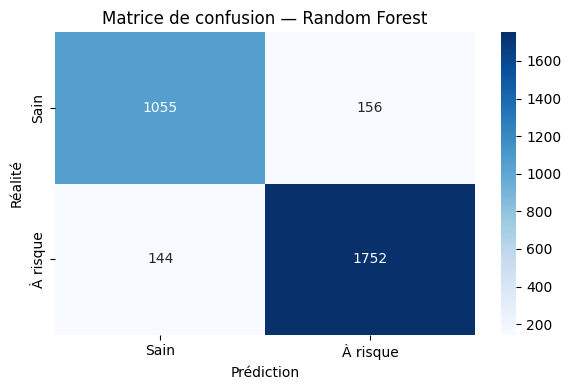

Vrais positifs  (malades bien détectés) : 1752
Faux négatifs   (malades manqués) ⚠️     : 144
Faux positifs   (fausses alarmes)        : 156
Vrais négatifs  (sains bien classés)     : 1055


In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sain', 'À risque'],
            yticklabels=['Sain', 'À risque'])
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de confusion — ' + meilleur_nom)
plt.tight_layout()
plt.show()

# lecture de la matrice
print("Vrais positifs  (malades bien détectés) :", cm[1, 1])
print("Faux négatifs   (malades manqués) ⚠️     :", cm[1, 0])
print("Faux positifs   (fausses alarmes)        :", cm[0, 1])
print("Vrais négatifs  (sains bien classés)     :", cm[0, 0])

 - Un graphique avec 4 cases : vrais positifs, faux négatifs, faux positifs, vrais négatifs
 - Plus les cases diagonales sont sombres → meilleur est le modèle
 - Les **faux négatifs** sont les plus importants à surveiller dans un contexte médical

## 8. Courbe d'apprentissage

Montre si le modèle sur-apprend ou s'il généralise bien.

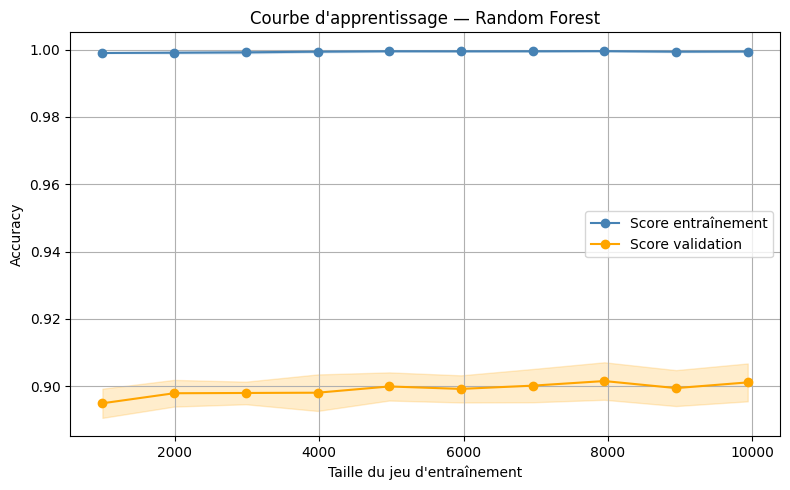

In [40]:
tailles, scores_train, scores_val = learning_curve(
    meilleur_pipeline, X_train, y_train,
    cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)  # on teste avec 10%, 20%... 100% du train
)

plt.figure(figsize=(8, 5))
plt.plot(tailles, scores_train.mean(axis=1), 'o-', color='steelblue', label='Score entraînement')
plt.plot(tailles, scores_val.mean(axis=1),   'o-', color='orange',    label='Score validation')

# zones d'incertitude (± écart-type)
plt.fill_between(tailles,
    scores_train.mean(axis=1) - scores_train.std(axis=1),
    scores_train.mean(axis=1) + scores_train.std(axis=1),
    alpha=0.2, color='steelblue')
plt.fill_between(tailles,
    scores_val.mean(axis=1) - scores_val.std(axis=1),
    scores_val.mean(axis=1) + scores_val.std(axis=1),
    alpha=0.2, color='orange')

plt.xlabel("Taille du jeu d'entraînement")
plt.ylabel("Accuracy")
plt.title("Courbe d'apprentissage — " + meilleur_nom)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

> - Courbe bleue : score sur les données d'entraînement
> - Courbe orange : score sur les données de validation
> - Si les deux courbes se rejoignent → le modèle généralise bien
> - Si la courbe bleue est très au-dessus de l'orange → le modèle sur-apprend (overfitting)

## 9. Sauvegarde du modèle

In [41]:
os.makedirs("models", exist_ok=True)  # on crée le dossier models s'il n'existe pas

# on sauvegarde le modèle dans un fichier .pkl
with open("models/modele_alzheimer.pkl", "wb") as f:
    pickle.dump(meilleur_pipeline, f)

print("Modèle sauvegardé : models/modele_alzheimer.pkl")
print("Modèle   :", meilleur_nom)
print("F1       :", f1)
print("Accuracy :", acc)

Modèle sauvegardé : models/modele_alzheimer.pkl
Modèle   : Random Forest
F1       : 0.9211
Accuracy : 0.9034


> **Ce qu'affiche cette cellule :**
> - Le chemin du fichier sauvegardé
> - Le nom du modèle et ses métriques finales
>
> Ce fichier sera chargé dans l'interface Streamlit pour prédire sur de nouveaux patients.

## 10. Inférence sur un nouveau patient

On simule l'arrivée d'un nouveau patient.
On part d'une ligne de X_train pour avoir exactement les bonnes colonnes,
puis on remplace les valeurs par celles du patient fictif.

In [42]:
# on prend la structure de X_train pour avoir les bonnes colonnes
nouveau_patient = X_train.iloc[[0]].copy()

# on remplace par les valeurs d'un patient fictif sain
nouveau_patient["CDGLOBAL"]  = 0.0   # score CDR global : 0 = normal
nouveau_patient["CDMEMORY"]  = 0.0   # mémoire : 0 = normal
nouveau_patient["CDRSB"]     = 0.0   # score CDR sum of boxes : 0 = normal
nouveau_patient["TOTSCORE"]  = 5.0   # score total
nouveau_patient["TOTAL13"]   = 5.0
nouveau_patient["CDJUDGE"]   = 0.0
nouveau_patient["MMSCORE"]   = 28.0  # score MMSE : 28/30 = normal
nouveau_patient["VSWEIGHT"]  = 70.0  # poids en kg
nouveau_patient["RtensionA"] = 1.625 # ratio tension artérielle (130/80)
nouveau_patient["VSPULSE"]   = 72.0  # pouls
nouveau_patient["CDHOME"]    = 0.0
nouveau_patient["VSBPSYS"]   = 130.0 # tension systolique
nouveau_patient["pressionP"] = 50.0  # pression différentielle (130-80)
nouveau_patient["CDCOMMUN"]  = 0.0
nouveau_patient["VSBPDIA"]   = 80.0  # tension diastolique
nouveau_patient["IMC"]       = 24.2  # indice de masse corporelle
nouveau_patient["WORD2DL"]   = 1.0

# prédiction
prediction = meilleur_pipeline.predict(nouveau_patient)[0]
proba      = meilleur_pipeline.predict_proba(nouveau_patient)[0, 1]

print("Résultat             :", "Sain (0)" if prediction == 0 else "À risque (1)")
print("Probabilité à risque :", round(proba * 100, 1), "%")

Résultat             : Sain (0)
Probabilité à risque : 12.0 %
